<a href="https://colab.research.google.com/github/RimeeAwasthi01/mnist-perceptron-ann-cnn/blob/main/mnist_perceptron_ann_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Handwritten Digit Recognition: Perceptron vs ANN vs CNN

## Objective
Recognise handwritten digits (0-9) and compare three models of increasing complexity:

1. **Perceptron-style model**: a single softmax layer (linear classifier)
2. **ANN**: a fully connected network with two hidden layers
3. **CNN**: a convolutional network that learns image features automatically

## Dataset
[MNIST in CSV format](https://www.kaggle.com/datasets/oddrationale/mnist-in-csv): 60,000 training and 10,000 test images of 28×28 grayscale pixels. Each row holds a `label` (0-9) and 784 pixel values (0-255).

## Workflow
1. Import libraries and load data
2. Inspect the data
3. Preprocess: normalise, reshape, one-hot encode
4. Train the Perceptron, ANN and CNN
5. Compare learning curves, predictions, confusion matrix and final accuracy

## 1. Import Libraries
- **Sequential**: builds a network layer by layer
- **Dense**: fully connected layer that makes the final predictions
- **Conv2D**: extracts visual features such as edges and strokes
- **MaxPooling2D**: reduces the spatial size of feature maps
- **Flatten**: converts 2D images / feature maps into a 1D vector
- **Dropout**: randomly switches off neurons during training to reduce overfitting
- **to_categorical**: one-hot encodes class labels

In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten

from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout

from tensorflow.keras.utils import to_categorical


## 2. Load and Inspect the Data
Load the training and test CSV files (keep them in the same folder as the notebook).

In [48]:
df = pd.read_csv("mnist_train.csv")
df_test = pd.read_csv("mnist_test.csv")

### 2.1 First rows
Each row is one image: the label followed by 784 pixel values.

In [49]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 2.2 Shape
60,000 training images, each with 1 label + 784 pixel columns.

In [50]:
df.shape

(60000, 785)

### 2.3 Column names
Pixel columns are named by position, from `1x1` to `28x28`.

In [51]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

### 2.4 Data types
All 785 columns are integers.

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


### 2.5 Missing values
Every column shows 0 missing values, so no cleaning is needed.

In [53]:
df.isnull().sum()

,0
label,0
1x1,0
1x2,0
1x3,0
1x4,0
...,...
28x24,0
28x25,0
28x26,0
28x27,0


## 3. Preprocessing

### 3.1 Split features and labels
Separate the `label` column (target) from the pixel columns (features).

In [54]:
X_train = df.drop("label", axis=1).values
y_train = df["label"].values
X_test = df_test.drop("label", axis=1).values
y_test = df_test["label"].values

### 3.2 Normalise pixel values
Pixels range from 0 to 255. Dividing by 255 scales them to 0-1, which makes training faster and more stable.

In [55]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

### 3.3 Reshape into 28×28 images
The Perceptron and ANN take 28×28 images and flatten them internally.

In [56]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

### 3.4 One-hot encode labels
Digit `5` becomes `[0,0,0,0,0,1,0,0,0,0]`, matching the 10-unit softmax output.

In [57]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

## 4. Model 1: Perceptron (single softmax layer)
No hidden layer: the image is flattened and connected straight to 10 output neurons. This is a **linear** classifier and serves as the baseline.

> A classic Perceptron uses a step function; this version uses softmax, the multi-class generalisation (softmax regression)

In [58]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

### Compile
SGD optimiser with categorical cross-entropy loss.

In [59]:
perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

### Train
5 epochs, batch size 32. The test set is used as validation data to watch performance after every epoch.

In [60]:
history_percp = perceptron.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8184 - loss: 0.7745 - val_accuracy: 0.8822 - val_loss: 0.4786
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8819 - loss: 0.4552 - val_accuracy: 0.8947 - val_loss: 0.3998
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8913 - loss: 0.4032 - val_accuracy: 0.9014 - val_loss: 0.3670
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8971 - loss: 0.3769 - val_accuracy: 0.9053 - val_loss: 0.3498
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9004 - loss: 0.3603 - val_accuracy: 0.9088 - val_loss: 0.3373


### Evaluate
Final test accuracy of the Perceptron.

In [61]:
acc_percp = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [62]:
acc_percp

0.9088000059127808

## 5. Model 2: ANN (fully connected network)
Two hidden layers (128 and 64 neurons) with ReLU add non-linearity, so the network can learn more complex patterns than a single linear layer.

In [63]:
#ANN
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

### Compile
Adam optimiser adapts the learning rate automatically.

In [64]:
ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

### Train

In [65]:
history_ann = ann.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9311 - loss: 0.2363 - val_accuracy: 0.9617 - val_loss: 0.1176
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9683 - loss: 0.1034 - val_accuracy: 0.9724 - val_loss: 0.0897
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9774 - loss: 0.0740 - val_accuracy: 0.9735 - val_loss: 0.0805
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9833 - loss: 0.0536 - val_accuracy: 0.9738 - val_loss: 0.0861
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9859 - loss: 0.0435 - val_accuracy: 0.9774 - val_loss: 0.0767


### Evaluate

In [66]:
acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [67]:
acc_ann

0.977400004863739

## 6. Model 3: CNN (convolutional network)

### 6.1 Reshape for the CNN
Convolutional layers need a channel dimension, so images become `28×28×1`.

In [68]:
X_train_cnn = X_train.reshape(-1, 28, 28,1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

### 6.2 Architecture
| Layer | Role |
|---|---|
| Conv2D (32, 3×3) + ReLU | detects low-level features such as edges |
| MaxPooling2D (2×2) | shrinks feature maps, keeping strong activations |
| Conv2D (64, 3×3) + ReLU | combines edges into shapes and strokes |
| MaxPooling2D (2×2) | shrinks again |
| Flatten | converts feature maps to a vector |
| Dense (128) + ReLU | classifies using the extracted features |
| Dropout (0.5) | reduces overfitting |
| Dense (10) + Softmax | digit probabilities |

Unlike the ANN, the CNN keeps the 2D spatial structure of the image, which is why it usually performs best on image data.

In [69]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

### 6.3 Compile

In [70]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

### 6.4 Train
The CNN takes noticeably longer per epoch than the other two models.

In [71]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_cnn, y_test_cat), verbose=1)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 29ms/step - accuracy: 0.9379 - loss: 0.2044 - val_accuracy: 0.9852 - val_loss: 0.0462
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 30ms/step - accuracy: 0.9780 - loss: 0.0744 - val_accuracy: 0.9875 - val_loss: 0.0372
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9825 - loss: 0.0591 - val_accuracy: 0.9905 - val_loss: 0.0297
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.9859 - loss: 0.0455 - val_accuracy: 0.9916 - val_loss: 0.0246
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9889 - loss: 0.0364 - val_accuracy: 0.9914 - val_loss: 0.0266


### 6.5 Evaluate

In [72]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]

In [73]:
acc_cnn

0.9914000034332275

## 7. Results and Comparison

### 7.1 Learning curves
A helper function plots accuracy and loss for training and validation. A growing gap between them would indicate overfitting.

In [74]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

**Perceptron**

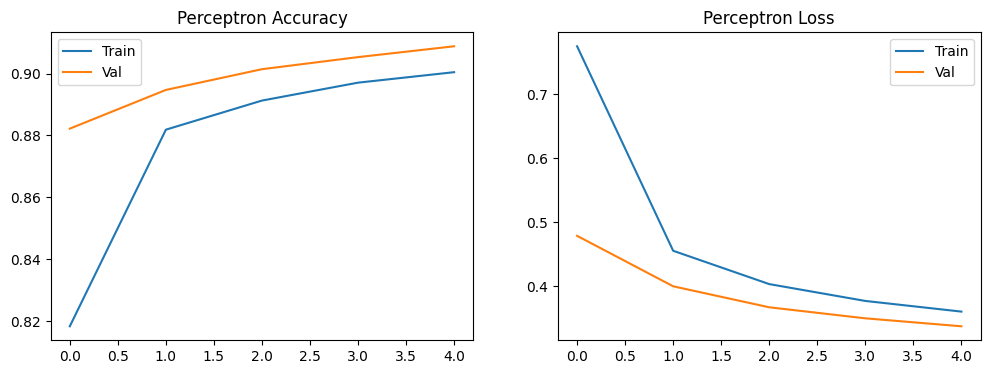

In [75]:
plot_training(history_percp, "Perceptron")

**ANN**

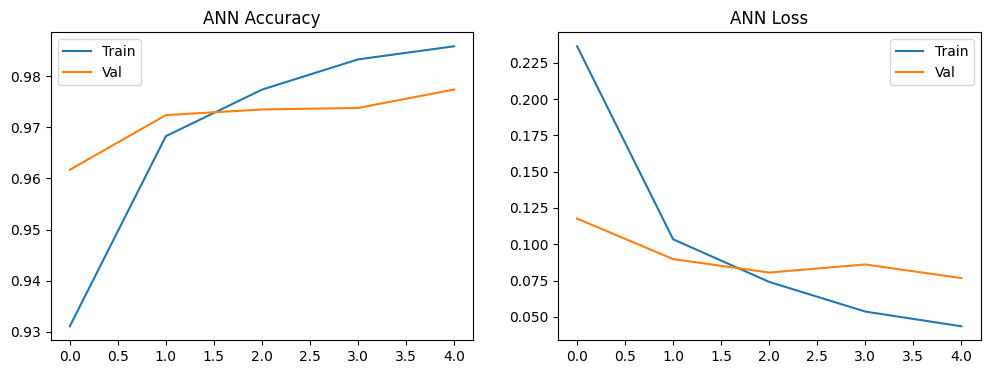

In [76]:
plot_training(history_ann, "ANN")

**CNN**

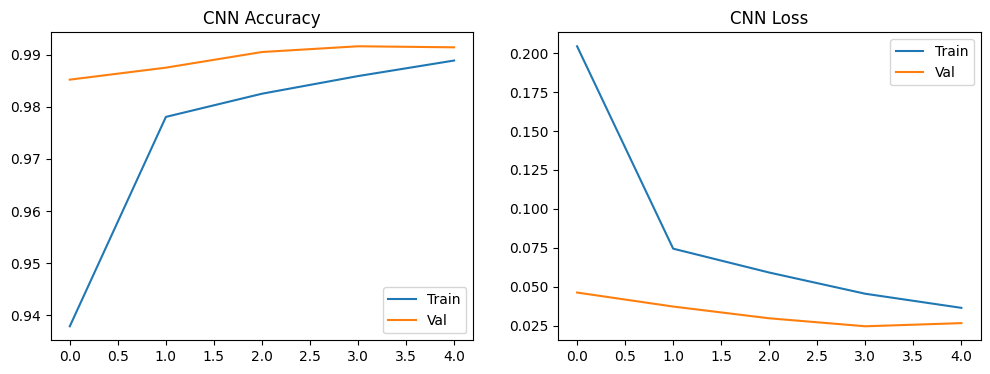

In [77]:
plot_training(history_cnn, "CNN")

### 7.2 Validation accuracy of all three models

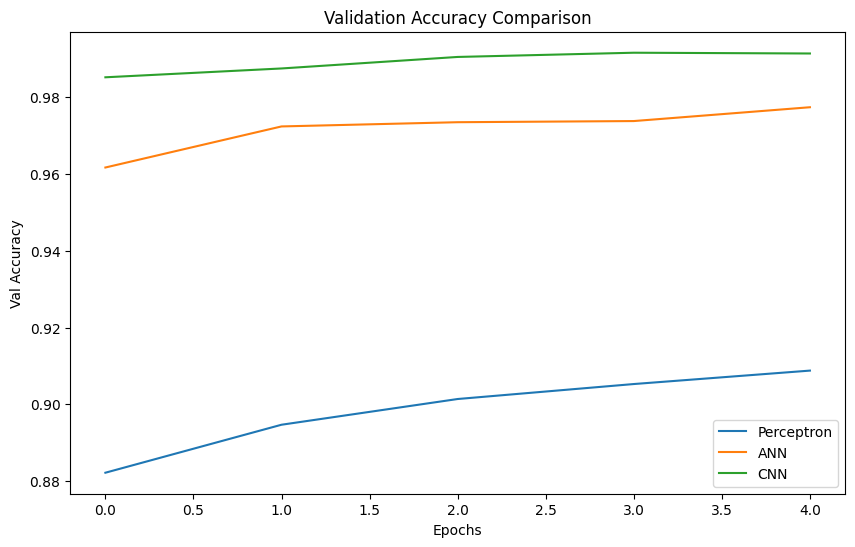

In [78]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

### 7.3 Predictions side by side
Random test images with the prediction from each model. The CNN needs 4D input; the other two use 3D.

In [79]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


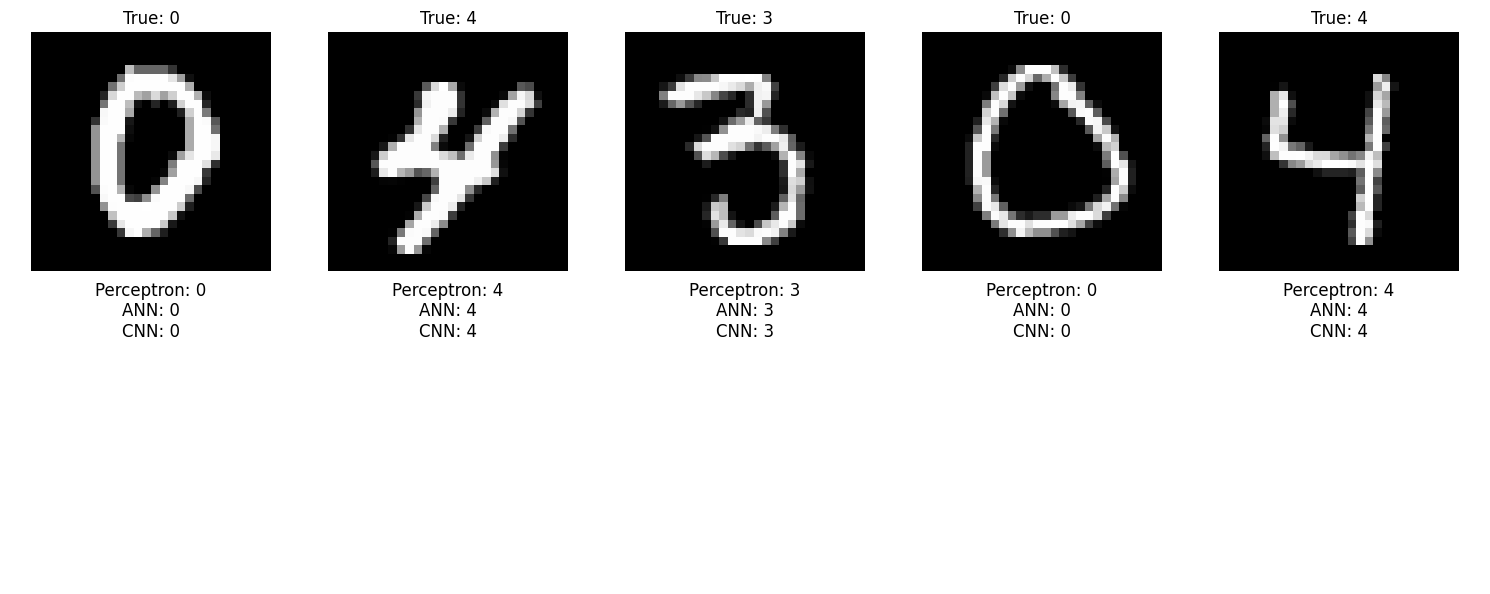

In [80]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)


### 7.4 CNN confusion matrix
Rows are true digits and columns are predictions. Off-diagonal cells show which digits get confused.

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


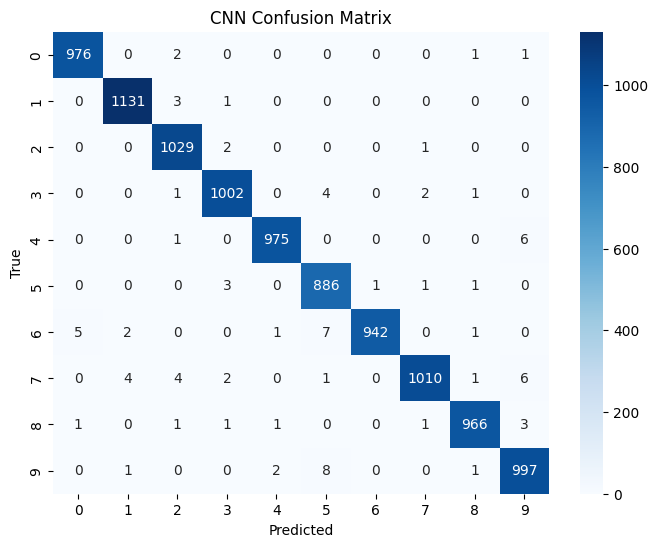

In [81]:
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### 7.5 Final accuracy comparison

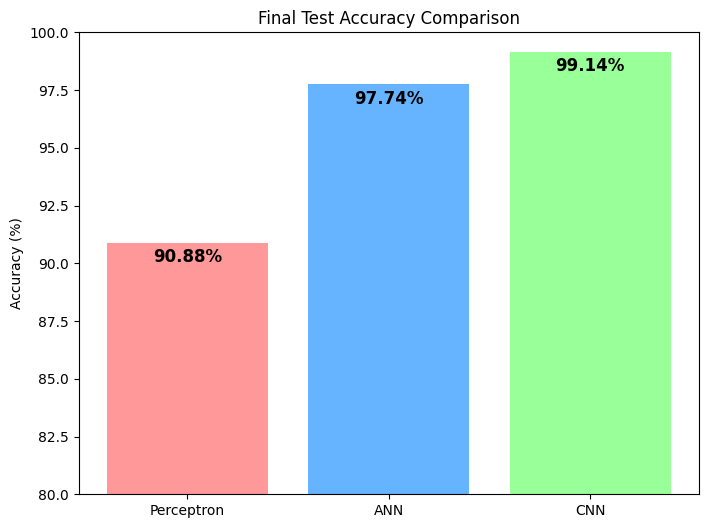

In [82]:
final_accs = [acc_percp*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()

## 8. Conclusions
- The **single-layer model** is limited to linear boundaries and has the lowest accuracy (about 90.8%).
- The **ANN** improves to about 97.7% by adding hidden layers, but it flattens the image and loses spatial structure.
- The **CNN** learns spatial features with convolutions and performs best (about 99.1%), at the cost of longer training time.
- The test set was used as validation data here. For a stricter evaluation, hold out a separate validation split from the training data.

## 9. Possible Extensions
- Train longer with early stopping
- Add data augmentation (small rotations and shifts)
- Try Fashion-MNIST or CIFAR-10
- Save the CNN and build a Streamlit app where users draw a digit